# Create Modelling Data for GAM
## Setup 
### Import Python Packages 

In [31]:
# External packages
import pandas as pd
import numpy as np
import sys
from pprint import pprint

# import random
# import os

import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns

# Internal packages
sys.path.append("../")
from src import utils

pd.set_option("display.max_columns", 100)

### Set Variables

In [32]:
# Fontsize for visualisation
tick_fontsize = 14
label_fontsize = 18
title_fontsize = 22

# Define the exposure and death counts (both actual and expected)
exposure = "Policies_Exposed"
act_death = "Death_Count"
exp_death = "ExpDth_VBT2015_Cnt"
exp_death_mi = "ExpDth_VBT2015wMI_Cnt"

# Define a dict that maps the counts to rates
count_to_rate_dict = {
    act_death: "act_death_rate", 
    exp_death: "exp_death_rate", 
    exp_death_mi: "exp_death_rate_mi"
} 

# Define holdout and random fold column names 
holdout = "holdout"
random_fold = "random_fold"
data_version = "_v2"

# Data
data_file = f"export/ILEC_2012_19 - 20240429 (Filtered Grouped by Selected Features){data_version}.parquet"

## Create Modelling Data
### Import Data

In [33]:
df_data = pd.read_parquet(data_file)
df_data

,Observation_Year,Sex,Smoker_Status,Insurance_Plan,Duration,Face_Amount_Band,Attained_Age,Issue_Age,Amount_Exposed,Policies_Exposed,Death_Claim_Amount,Death_Count,ExpDth_VBT2015_Cnt,ExpDth_VBT2015wMI_Cnt
0,2013,M,NS,Term,13,"08: 1,000,000 - 2,499,999",49,37,2.816249e+09,2373.825295,1000000.0,1.0,2.825380,2.861795
1,2013,M,NS,Term,4,"05: 100,000 - 249,999",43,40,4.122088e+08,2885.065642,300000.0,2.0,1.497143,1.516439
2,2013,M,NS,Term,7,"07: 500,000 - 999,999",45,39,4.333897e+09,7621.606277,3000000.0,5.0,5.458652,5.529007
3,2013,M,NS,Term,1,"08: 1,000,000 - 2,499,999",39,39,8.017922e+09,6353.052547,0.0,0.0,1.016488,1.029590
4,2013,M,NS,Term,7,"05: 100,000 - 249,999",48,42,4.234805e+08,2958.868927,700000.0,5.0,2.586733,2.620072
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
458593,2013,F,NS,Term,8,"01: 0 - 9,999",51,44,3.181642e+02,0.805479,0.0,0.0,0.000749,0.000756
458594,2015,F,S,Term,35,"03: 25,000 - 49,999",72,38,2.234141e+04,0.595628,0.0,0.0,0.015814,0.015814
458595,2015,F,S,Term,28,"01: 0 - 9,999",83,56,2.486340e+03,0.497268,0.0,0.0,0.036062,0.036062
458596,2018,F,S,Term,2,"09: 2,500,000 - 4,999,999",60,59,2.180822e+06,0.545205,0.0,0.0,0.001510,0.001489


### Map categorical levels to integer values

In [35]:
##################################################################
##################################################################

# Define a list of categorical variables
cat_feat = ["Sex", "Smoker_Status"]

# Define the categorical banding output
output_cat_map = f"export/SOA Categorical Mapping{data_version}.xlsx"

##################################################################
##################################################################

# Save categorical mappings
with pd.ExcelWriter(output_cat_map, engine="openpyxl") as writer:
    for var in cat_feat:
        # Create a dataframe that contains the unique values and their associated integer values
        df_ = pd.DataFrame(df_data[var].unique(), columns=["Categorical_Level"])
        df_.sort_values("Categorical_Level", inplace=True)
        df_["Integer_Value"] = list(range(len(df_)))

        # Save the mapping table
        df_.to_excel(writer, sheet_name=var, index=False)

        # Map the categorical variable into integer values
        df_data[var + "_cat_level"] = df_data[var].map(
            df_.set_index("Categorical_Level").to_dict()["Integer_Value"]
        )

df_data

,Observation_Year,Sex,Smoker_Status,Insurance_Plan,Duration,Face_Amount_Band,Attained_Age,Issue_Age,Amount_Exposed,Policies_Exposed,Death_Claim_Amount,Death_Count,ExpDth_VBT2015_Cnt,ExpDth_VBT2015wMI_Cnt,Sex_cat_level,Smoker_Status_cat_level
0,2013,M,NS,Term,13,"08: 1,000,000 - 2,499,999",49,37,2.816249e+09,2373.825295,1000000.0,1.0,2.825380,2.861795,1,0
1,2013,M,NS,Term,4,"05: 100,000 - 249,999",43,40,4.122088e+08,2885.065642,300000.0,2.0,1.497143,1.516439,1,0
2,2013,M,NS,Term,7,"07: 500,000 - 999,999",45,39,4.333897e+09,7621.606277,3000000.0,5.0,5.458652,5.529007,1,0
3,2013,M,NS,Term,1,"08: 1,000,000 - 2,499,999",39,39,8.017922e+09,6353.052547,0.0,0.0,1.016488,1.029590,1,0
4,2013,M,NS,Term,7,"05: 100,000 - 249,999",48,42,4.234805e+08,2958.868927,700000.0,5.0,2.586733,2.620072,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
458593,2013,F,NS,Term,8,"01: 0 - 9,999",51,44,3.181642e+02,0.805479,0.0,0.0,0.000749,0.000756,0,0
458594,2015,F,S,Term,35,"03: 25,000 - 49,999",72,38,2.234141e+04,0.595628,0.0,0.0,0.015814,0.015814,0,1
458595,2015,F,S,Term,28,"01: 0 - 9,999",83,56,2.486340e+03,0.497268,0.0,0.0,0.036062,0.036062,0,1
458596,2018,F,S,Term,2,"09: 2,500,000 - 4,999,999",60,59,2.180822e+06,0.545205,0.0,0.0,0.001510,0.001489,0,1


In [36]:
####################################################################
####################################################################

var = "Sex"
format_dict = {exposure: "{:,.0f}"}
bar_dict = {exposure: "grey"}
caption = f"{var} Distribution"

####################################################################
####################################################################

# Check the distribution of one categorical variable and its integer values 
df_gb = df_data.groupby([var, var + "_cat_level"], dropna=False)[[exposure]].sum()

# Display result
df_gb.style.pipe(
    lambda x: utils.make_pretty_pivot(x, format_dict, caption, bar_dict=bar_dict)
)

,,Policies_Exposed
Sex,Sex_cat_level,
F,0,"74,907,716"
M,1,"94,383,622"


### Convert Face_Amount_Band into ordinal variable

In [37]:
df_data["Face_Amount_Band_ordinal"] = df_data["Face_Amount_Band"].str[:2].astype(int)
df_data

,Observation_Year,Sex,Smoker_Status,Insurance_Plan,Duration,Face_Amount_Band,Attained_Age,Issue_Age,Amount_Exposed,Policies_Exposed,Death_Claim_Amount,Death_Count,ExpDth_VBT2015_Cnt,ExpDth_VBT2015wMI_Cnt,Sex_cat_level,Smoker_Status_cat_level,Face_Amount_Band_ordinal
0,2013,M,NS,Term,13,"08: 1,000,000 - 2,499,999",49,37,2.816249e+09,2373.825295,1000000.0,1.0,2.825380,2.861795,1,0,8
1,2013,M,NS,Term,4,"05: 100,000 - 249,999",43,40,4.122088e+08,2885.065642,300000.0,2.0,1.497143,1.516439,1,0,5
2,2013,M,NS,Term,7,"07: 500,000 - 999,999",45,39,4.333897e+09,7621.606277,3000000.0,5.0,5.458652,5.529007,1,0,7
3,2013,M,NS,Term,1,"08: 1,000,000 - 2,499,999",39,39,8.017922e+09,6353.052547,0.0,0.0,1.016488,1.029590,1,0,8
4,2013,M,NS,Term,7,"05: 100,000 - 249,999",48,42,4.234805e+08,2958.868927,700000.0,5.0,2.586733,2.620072,1,0,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
458593,2013,F,NS,Term,8,"01: 0 - 9,999",51,44,3.181642e+02,0.805479,0.0,0.0,0.000749,0.000756,0,0,1
458594,2015,F,S,Term,35,"03: 25,000 - 49,999",72,38,2.234141e+04,0.595628,0.0,0.0,0.015814,0.015814,0,1,3
458595,2015,F,S,Term,28,"01: 0 - 9,999",83,56,2.486340e+03,0.497268,0.0,0.0,0.036062,0.036062,0,1,1
458596,2018,F,S,Term,2,"09: 2,500,000 - 4,999,999",60,59,2.180822e+06,0.545205,0.0,0.0,0.001510,0.001489,0,1,9


In [38]:
####################################################################
####################################################################

var = "Face_Amount_Band"
format_dict = {exposure: "{:,.0f}"}
bar_dict = {exposure: "grey"}
caption = f"{var} Distribution"

####################################################################
####################################################################

# Check its distribution
df_gb = df_data.groupby([var, var + "_ordinal"], dropna=False)[[exposure]].sum()

# Display result
df_gb.style.pipe(
    lambda x: utils.make_pretty_pivot(x, format_dict, caption, bar_dict=bar_dict)
)

,,Policies_Exposed
Face_Amount_Band,Face_Amount_Band_ordinal,
"01: 0 - 9,999",1,"368,701"
"02: 10,000 - 24,999",2,"1,508,568"
"03: 25,000 - 49,999",3,"3,494,476"
"04: 50,000 - 99,999",4,"9,090,441"
"05: 100,000 - 249,999",5,"49,292,183"
"06: 250,000 - 499,999",6,"48,425,727"
"07: 500,000 - 999,999",7,"34,875,999"
"08: 1,000,000 - 2,499,999",8,"20,215,207"
"09: 2,500,000 - 4,999,999",9,"1,446,721"


### Cap Duration 
Duration above 20 behaves strangely - could be due to anti-selection, hence the capping

In [39]:
df_data["Duration"] = np.where(df_data["Duration"] <= 20, df_data["Duration"], 20)

In [40]:
####################################################################
####################################################################

var = "Duration"
format_dict = {exposure: "{:,.0f}"}
bar_dict = {exposure: "grey"}
caption = f"{var} Distribution"

####################################################################
####################################################################

# Check its distribution
df_gb = df_data.groupby([var], dropna=False)[[exposure]].sum()

# Display result
df_gb.style.pipe(
    lambda x: utils.make_pretty_pivot(x, format_dict, caption, bar_dict=bar_dict)
)

,Policies_Exposed
Duration,
1,"12,282,543"
2,"11,289,493"
3,"10,728,998"
4,"10,445,317"
5,"10,193,880"
6,"9,911,178"
7,"9,708,034"
8,"9,582,746"
9,"9,521,811"


### Define Training/Holdout Sets and Random Folds

In [41]:
# Set the last two observation years as the holdout
df_data[holdout] = np.where(df_data["Observation_Year"].isin([2018, 2019]), 1, 0)
df_data

,Observation_Year,Sex,Smoker_Status,Insurance_Plan,Duration,Face_Amount_Band,Attained_Age,Issue_Age,Amount_Exposed,Policies_Exposed,Death_Claim_Amount,Death_Count,ExpDth_VBT2015_Cnt,ExpDth_VBT2015wMI_Cnt,Sex_cat_level,Smoker_Status_cat_level,Face_Amount_Band_ordinal,holdout
0,2013,M,NS,Term,13,"08: 1,000,000 - 2,499,999",49,37,2.816249e+09,2373.825295,1000000.0,1.0,2.825380,2.861795,1,0,8,0
1,2013,M,NS,Term,4,"05: 100,000 - 249,999",43,40,4.122088e+08,2885.065642,300000.0,2.0,1.497143,1.516439,1,0,5,0
2,2013,M,NS,Term,7,"07: 500,000 - 999,999",45,39,4.333897e+09,7621.606277,3000000.0,5.0,5.458652,5.529007,1,0,7,0
3,2013,M,NS,Term,1,"08: 1,000,000 - 2,499,999",39,39,8.017922e+09,6353.052547,0.0,0.0,1.016488,1.029590,1,0,8,0
4,2013,M,NS,Term,7,"05: 100,000 - 249,999",48,42,4.234805e+08,2958.868927,700000.0,5.0,2.586733,2.620072,1,0,5,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
458593,2013,F,NS,Term,8,"01: 0 - 9,999",51,44,3.181642e+02,0.805479,0.0,0.0,0.000749,0.000756,0,0,1,0
458594,2015,F,S,Term,20,"03: 25,000 - 49,999",72,38,2.234141e+04,0.595628,0.0,0.0,0.015814,0.015814,0,1,3,0
458595,2015,F,S,Term,20,"01: 0 - 9,999",83,56,2.486340e+03,0.497268,0.0,0.0,0.036062,0.036062,0,1,1,0
458596,2018,F,S,Term,2,"09: 2,500,000 - 4,999,999",60,59,2.180822e+06,0.545205,0.0,0.0,0.001510,0.001489,0,1,9,1


In [42]:
#####################################################################################
#####################################################################################

seed = 2026
num_fold = 5

#####################################################################################
#####################################################################################

# Define a column for random folds for cross validations
np.random.seed(seed)
df_data[random_fold] = np.random.randint(1, num_fold + 1, len(df_data))
df_data[random_fold] = np.where(
    df_data[holdout] == 0, df_data[random_fold], num_fold + 1
)
df_data

,Observation_Year,Sex,Smoker_Status,Insurance_Plan,Duration,Face_Amount_Band,Attained_Age,Issue_Age,Amount_Exposed,Policies_Exposed,Death_Claim_Amount,Death_Count,ExpDth_VBT2015_Cnt,ExpDth_VBT2015wMI_Cnt,Sex_cat_level,Smoker_Status_cat_level,Face_Amount_Band_ordinal,holdout,random_fold
0,2013,M,NS,Term,13,"08: 1,000,000 - 2,499,999",49,37,2.816249e+09,2373.825295,1000000.0,1.0,2.825380,2.861795,1,0,8,0,2
1,2013,M,NS,Term,4,"05: 100,000 - 249,999",43,40,4.122088e+08,2885.065642,300000.0,2.0,1.497143,1.516439,1,0,5,0,3
2,2013,M,NS,Term,7,"07: 500,000 - 999,999",45,39,4.333897e+09,7621.606277,3000000.0,5.0,5.458652,5.529007,1,0,7,0,1
3,2013,M,NS,Term,1,"08: 1,000,000 - 2,499,999",39,39,8.017922e+09,6353.052547,0.0,0.0,1.016488,1.029590,1,0,8,0,5
4,2013,M,NS,Term,7,"05: 100,000 - 249,999",48,42,4.234805e+08,2958.868927,700000.0,5.0,2.586733,2.620072,1,0,5,0,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
458593,2013,F,NS,Term,8,"01: 0 - 9,999",51,44,3.181642e+02,0.805479,0.0,0.0,0.000749,0.000756,0,0,1,0,3
458594,2015,F,S,Term,20,"03: 25,000 - 49,999",72,38,2.234141e+04,0.595628,0.0,0.0,0.015814,0.015814,0,1,3,0,3
458595,2015,F,S,Term,20,"01: 0 - 9,999",83,56,2.486340e+03,0.497268,0.0,0.0,0.036062,0.036062,0,1,1,0,1
458596,2018,F,S,Term,2,"09: 2,500,000 - 4,999,999",60,59,2.180822e+06,0.545205,0.0,0.0,0.001510,0.001489,0,1,9,1,6


In [43]:
####################################################################
####################################################################

var = [random_fold, holdout]

format_dict = {
    exposure: "{:,.0f}",
    **{k: "{:,.0f}" for k, _ in count_to_rate_dict.items()},
    **{v: "{:,.4%}" for _, v in count_to_rate_dict.items()},
}
bar_dict = {
    exposure: "grey",
    **{k: "grey" for k, _ in count_to_rate_dict.items()},
    **{v: "blue" for _, v in count_to_rate_dict.items()},
}
caption = f"{var} Distribution"

####################################################################
####################################################################

# Check its distribution and the actual and expected death rates
df_gb = df_data.groupby(var, dropna=False)[
    [exposure, act_death, exp_death, exp_death_mi]
].sum()

for k, v in count_to_rate_dict.items():
    df_gb[v] = df_gb[k] / df_gb[exposure]

# Display result
df_gb.style.pipe(
    lambda x: utils.make_pretty_pivot(x, format_dict, caption, bar_dict=bar_dict)
)

,,Policies_Exposed,Death_Count,ExpDth_VBT2015_Cnt,ExpDth_VBT2015wMI_Cnt,act_death_rate,exp_death_rate,exp_death_rate_mi
random_fold,holdout,,,,,,,
1,0,"24,717,784","48,703","44,741","44,815",0.1970%,0.1810%,0.1813%
2,0,"24,453,727","47,871","43,690","43,755",0.1958%,0.1787%,0.1789%
3,0,"24,841,681","48,837","44,517","44,593",0.1966%,0.1792%,0.1795%
4,0,"24,648,122","48,001","43,931","44,002",0.1947%,0.1782%,0.1785%
5,0,"24,766,280","48,386","44,463","44,532",0.1954%,0.1795%,0.1798%
6,1,"45,863,746","102,583","101,550","99,498",0.2237%,0.2214%,0.2169%


### Create normalised target variables
PyGAM doesn't have an offset functionality, hence the need to create actual and expected death rates. 

In [44]:
for k, v in count_to_rate_dict.items(): 
    df_data[v] = df_data[k] / df_data[exposure]
df_data

,Observation_Year,Sex,Smoker_Status,Insurance_Plan,Duration,Face_Amount_Band,Attained_Age,Issue_Age,Amount_Exposed,Policies_Exposed,Death_Claim_Amount,Death_Count,ExpDth_VBT2015_Cnt,ExpDth_VBT2015wMI_Cnt,Sex_cat_level,Smoker_Status_cat_level,Face_Amount_Band_ordinal,holdout,random_fold,act_death_rate,exp_death_rate,exp_death_rate_mi
0,2013,M,NS,Term,13,"08: 1,000,000 - 2,499,999",49,37,2.816249e+09,2373.825295,1000000.0,1.0,2.825380,2.861795,1,0,8,0,2,0.000421,0.001190,0.001206
1,2013,M,NS,Term,4,"05: 100,000 - 249,999",43,40,4.122088e+08,2885.065642,300000.0,2.0,1.497143,1.516439,1,0,5,0,3,0.000693,0.000519,0.000526
2,2013,M,NS,Term,7,"07: 500,000 - 999,999",45,39,4.333897e+09,7621.606277,3000000.0,5.0,5.458652,5.529007,1,0,7,0,1,0.000656,0.000716,0.000725
3,2013,M,NS,Term,1,"08: 1,000,000 - 2,499,999",39,39,8.017922e+09,6353.052547,0.0,0.0,1.016488,1.029590,1,0,8,0,5,0.000000,0.000160,0.000162
4,2013,M,NS,Term,7,"05: 100,000 - 249,999",48,42,4.234805e+08,2958.868927,700000.0,5.0,2.586733,2.620072,1,0,5,0,5,0.001690,0.000874,0.000885
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
458593,2013,F,NS,Term,8,"01: 0 - 9,999",51,44,3.181642e+02,0.805479,0.0,0.0,0.000749,0.000756,0,0,1,0,3,0.000000,0.000930,0.000939
458594,2015,F,S,Term,20,"03: 25,000 - 49,999",72,38,2.234141e+04,0.595628,0.0,0.0,0.015814,0.015814,0,1,3,0,3,0.000000,0.026550,0.026550
458595,2015,F,S,Term,20,"01: 0 - 9,999",83,56,2.486340e+03,0.497268,0.0,0.0,0.036062,0.036062,0,1,1,0,1,0.000000,0.072520,0.072520
458596,2018,F,S,Term,2,"09: 2,500,000 - 4,999,999",60,59,2.180822e+06,0.545205,0.0,0.0,0.001510,0.001489,0,1,9,1,6,0.000000,0.002770,0.002730


### Set Unique ID

In [45]:
df_data.index.name = "unique_id"
df_data

,Observation_Year,Sex,Smoker_Status,Insurance_Plan,Duration,Face_Amount_Band,Attained_Age,Issue_Age,Amount_Exposed,Policies_Exposed,Death_Claim_Amount,Death_Count,ExpDth_VBT2015_Cnt,ExpDth_VBT2015wMI_Cnt,Sex_cat_level,Smoker_Status_cat_level,Face_Amount_Band_ordinal,holdout,random_fold,act_death_rate,exp_death_rate,exp_death_rate_mi
unique_id,,,,,,,,,,,,,,,,,,,,,,
0,2013,M,NS,Term,13,"08: 1,000,000 - 2,499,999",49,37,2.816249e+09,2373.825295,1000000.0,1.0,2.825380,2.861795,1,0,8,0,2,0.000421,0.001190,0.001206
1,2013,M,NS,Term,4,"05: 100,000 - 249,999",43,40,4.122088e+08,2885.065642,300000.0,2.0,1.497143,1.516439,1,0,5,0,3,0.000693,0.000519,0.000526
2,2013,M,NS,Term,7,"07: 500,000 - 999,999",45,39,4.333897e+09,7621.606277,3000000.0,5.0,5.458652,5.529007,1,0,7,0,1,0.000656,0.000716,0.000725
3,2013,M,NS,Term,1,"08: 1,000,000 - 2,499,999",39,39,8.017922e+09,6353.052547,0.0,0.0,1.016488,1.029590,1,0,8,0,5,0.000000,0.000160,0.000162
4,2013,M,NS,Term,7,"05: 100,000 - 249,999",48,42,4.234805e+08,2958.868927,700000.0,5.0,2.586733,2.620072,1,0,5,0,5,0.001690,0.000874,0.000885
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
458593,2013,F,NS,Term,8,"01: 0 - 9,999",51,44,3.181642e+02,0.805479,0.0,0.0,0.000749,0.000756,0,0,1,0,3,0.000000,0.000930,0.000939
458594,2015,F,S,Term,20,"03: 25,000 - 49,999",72,38,2.234141e+04,0.595628,0.0,0.0,0.015814,0.015814,0,1,3,0,3,0.000000,0.026550,0.026550
458595,2015,F,S,Term,20,"01: 0 - 9,999",83,56,2.486340e+03,0.497268,0.0,0.0,0.036062,0.036062,0,1,1,0,1,0.000000,0.072520,0.072520


### Correlation Matrix

[Text(0.5, 0, 'act_death_rate'),
 Text(1.5, 0, 'exp_death_rate'),
 Text(2.5, 0, 'exp_death_rate_mi'),
 Text(3.5, 0, 'Observation_Year'),
 Text(4.5, 0, 'Duration'),
 Text(5.5, 0, 'Attained_Age'),
 Text(6.5, 0, 'Issue_Age'),
 Text(7.5, 0, 'Face_Amount_Band_ordinal'),
 Text(8.5, 0, 'Sex_cat_level'),
 Text(9.5, 0, 'Smoker_Status_cat_level')]

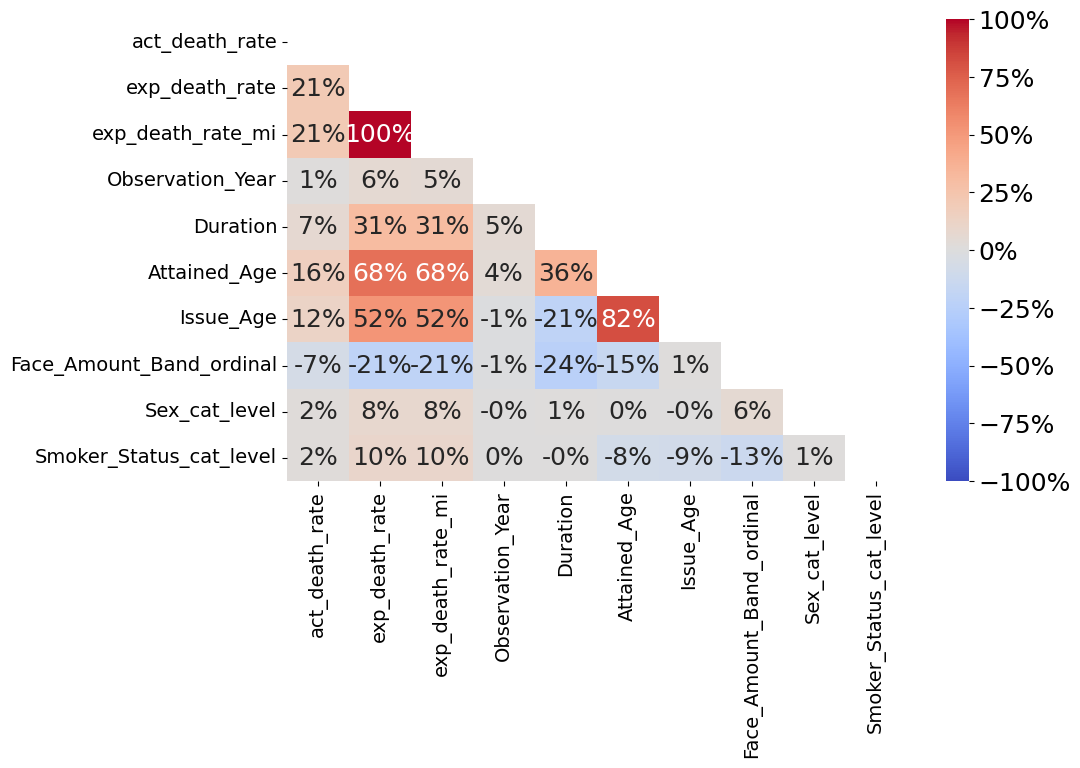

In [46]:
##########################################################################
##########################################################################

# Define a list of column names in-scope for correlation analysis
col_for_corr_list = [
    *[v for _, v in count_to_rate_dict.items()],
    "Observation_Year",
    "Duration",
    "Attained_Age",
    "Issue_Age",
    "Face_Amount_Band_ordinal",
    *[x + "_cat_level" for x in cat_feat],
]

##########################################################################
##########################################################################

corr_mat = round(df_data[col_for_corr_list].corr(), 2)

# Fill diagonal and upper half with NaNs
mask = np.zeros_like(corr_mat, dtype=bool)
mask[np.triu_indices_from(mask)] = True
corr_mat[mask] = np.nan

fig, ax = plt.subplots(figsize=(10, 6))
ax = sns.heatmap(
    corr_mat,
    annot=True,
    annot_kws={"size": label_fontsize},
    fmt=".0%",
    vmin=-1,
    vmax=1,
    cmap="coolwarm",
)

colorbar = ax.collections[0].colorbar
colorbar.ax.tick_params(labelsize=label_fontsize)
colorbar.ax.yaxis.set_major_formatter(mtick.PercentFormatter(1))

ax.set_facecolor("white")
ax.set_yticklabels(df_data[col_for_corr_list].columns, fontsize=tick_fontsize)
ax.set_xticklabels(df_data[col_for_corr_list].columns, fontsize=tick_fontsize)

## Export files

In [ ]:
###########################################################################
###########################################################################

model_data_output = f"export/Modelling_data (Filtered and Grouped by Selected Features){data_version}.parquet"

###########################################################################
###########################################################################

df_data.to_parquet(
    f"{model_data_output}",
    engine="pyarrow",
    compression="gzip",
)